# Using the CRISP-DM Method for MLN 601 Machine Learning
# Assessment 1: Regression Analysis

**Student:** Nomayer Hossain

**Subject:** MLN601 Machine Learning

Torrens University Australia

Adapted from Smart Vision Europe (2020) https://www.sv-europe.com/crisp-dm-methodology/ and Patience (2018) https://grantpatience.com/2018/10/30/applying-crisp-dm-to-data-science-and-a-re-usable-template-in-jupyter/

CRISP-DM stands for cross-industry process for data mining. The CRISP steps are:

1. Gain an understanding of the business
2. Gain an understanding of the data
3. Prepare the data
4. Complete modeling
5. Evaluate
6. Deploy

# 1. Stage One - Determine Business Objectives and Assess the Situation <a class="anchor"></a>

This Notebook predicts **red wine quality** (0–10 sensory score) from 11 physicochemical attributes using **linear regression**.

Wine quality is normally assessed by an expert sensory panel which is slow, expensive, and subjective. Every batch, however, already has physicochemical lab data recorded routinely (acidity, sugar, alcohol, sulphates, etc.). If a reliable statistical relationship exists between chemistry and sensory score, a winery could use predictive modelling for **early-stage quality triage**: flagging likely below-average batches before bottling, directing expert tasting time toward borderline batches, and adding a consistent, auditable basis to quality decisions, without claiming to fully replace expert judgement.

**Scope decision —> Red Wine only:** Although the UCI repository provides both a red and a white wine dataset, this analysis focuses exclusively on **red wine**. Red and white wines are produced through different processes (red wine is fermented with grape skins; white typically is not), producing systematically different chemical profiles. Pooling both types risks confounding the chemistry–quality relationship, since the same chemical value could indicate different quality outcomes depending on wine type. Treating red wine as a single, homogeneous population, consistent with the original UCI file structure produces a cleaner, more interpretable model.

**Why linear regression:** Quality is a numeric, ordered target, making this a regression task. Linear regression is interpretable, its coefficients directly show which chemical properties increase or decrease predicted quality, and by how much. It is computationally light, and provides a transparent benchmark for later comparison against more complex algorithms.

**Success criteria:** the model will be assessed using R² (variance explained), RMSE (average error in quality points), and residual analysis. A perfect R² of 1.0 is not expected, since sensory quality has a genuine subjective component that chemistry alone cannot capture. The goal is a model that adds real decision-support value, not one that replaces human judgement outright.

## 1.1 Assess the Current Situation <a class="anchor"></a>

- **Personnel:** Nomayer Hossain
- **Data:** UCI Machine Learning Repository, Wine Quality dataset (red wine subset). 1,599 observations, 11 physicochemical input variables, 1 sensory output variable (`quality`).
- **Computing resources:** Google Colab (cloud-hosted, free tier).
- **Software:** Python 3, with `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` (specifically `LinearRegression`, `train_test_split`, `StandardScaler`, and the `sklearn.metrics` module).

# 2. Stage Two - Data Understanding <a class="anchor"></a>

## 2.1 Initial Data Acquisition <a class="anchor"></a>

- **Source:** UCI Machine Learning Repository —> Wine Quality dataset: https://archive.ics.uci.edu/ml/datasets/wine+quality
- **File used:** `winequality-red.csv` (red wine subset only; see Section 1 for rationale)
- **Method of acquisition:** The file was downloaded from the UCI repository and read into this Notebook using `pandas.read_csv()`. Note the file uses a **semicolon (`;`)** delimiter rather than a comma, as confirmed by inspecting the raw file and the UCI data description (`winequality.names`).
- **Problems encountered:** None. The file loading was clean with no parsing errors once the correct delimiter was identified.
- **Citation:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T. & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547–553.

In [1]:
# Import Libraries Required
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
# Data source: UCI Machine Learning Repository: Red Wine Quality
# Source: https://archive.ics.uci.edu/ml/datasets/wine+quality
# File: winequality-red.csv (uploaded to this Colab session)
# Note: file uses ';' as delimiter (per UCI documentation)

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
    sep=';'
)

print(f"Dataset loaded successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully. Shape: 1599 rows, 12 columns


## 2.2 Describe Data <a class="anchor"></a>

The dataset contains 1,599 observations of red *Vinho Verde* wine samples from northern Portugal, with 11 physicochemical input variables and 1 sensory output variable (`quality`).

In [3]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [4]:
df.shape

(1599, 12)

In [5]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [6]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [7]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
# Full variable description table: units and roles, sourced from the
# UCI dataset documentation (winequality.names) and Cortez et al. (2009)

variable_descriptions = pd.DataFrame({
    "Variable": ["fixed acidity","volatile acidity","citric acid","residual sugar",
                 "chlorides","free sulfur dioxide","total sulfur dioxide","density",
                 "pH","sulphates","alcohol","quality"],
    "Unit": ["g(tartaric acid)/dm³","g(acetic acid)/dm³","g/dm³","g/dm³",
             "g(NaCl)/dm³","mg/dm³","mg/dm³","g/cm³","pH scale (0–14)",
             "g(K2SO4)/dm³","% vol.","score (0–10)"],
    "Role": ["Independent"]*11 + ["Dependent (target)"]
})
variable_descriptions

,Variable,Unit,Role
0,fixed acidity,g(tartaric acid)/dm³,Independent
1,volatile acidity,g(acetic acid)/dm³,Independent
2,citric acid,g/dm³,Independent
3,residual sugar,g/dm³,Independent
4,chlorides,g(NaCl)/dm³,Independent
5,free sulfur dioxide,mg/dm³,Independent
6,total sulfur dioxide,mg/dm³,Independent
7,density,g/cm³,Independent
8,pH,pH scale (0–14),Independent
9,sulphates,g(K2SO4)/dm³,Independent


**Evaluation:** the dataset satisfies the requirements for this regression task. It provides 11 numeric physicochemical predictors and a numeric sensory target, with a sample size (1,599) sufficient for fitting and evaluating a linear regression model with a held-out test set.

## 2.3 Verify Data Quality <a class="anchor"></a>

In [10]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0
Total duplicate rows: 240


**Data quality observations:** The dataset has **no missing values** across any of the 12 columns. However, there **are 240 duplicate rows** (15% of the dataset), exact repeats across all 12 columns. This is addressed in Stage 3 (Data Preparation), since leaving duplicates in place risks giving certain chemical combinations disproportionate influence on the fitted model, and risks leaking the same observation across both the training and test sets if it is split by chance.

### 2.3.1 Outliers <a class="anchor"></a>

Although outlier removal is not required for this assessment (per the assessment brief), a visual boxplot scan (Section 3.2) is still included to document any extreme values observed, without removing them.

## 2.4 Initial Data Exploration <a class="anchor"></a>

### 2.4.1 Distributions <a class="anchor"></a>

In [11]:
# 2.4.1 Distributions: Quality Score Frequency Table
# Shows count and percentage of wines at each quality score (3–8)
def count_values_table(df):
    count_val = df.value_counts()
    count_val_percent = 100 * df.value_counts() / len(df)
    count_val_table = pd.concat([count_val, count_val_percent.round(1)], axis=1)
    count_val_table_ren_columns = count_val_table.rename(
        columns={0: 'Count Values', 1: '% of Total Values'})
    return count_val_table_ren_columns

count_values_table(df["quality"])

# Reveals class imbalance: scores 5 and 6 dominate the dataset

,count,count
quality,,
5,681,42.6
6,638,39.9
7,199,12.4
4,53,3.3
8,18,1.1
3,10,0.6


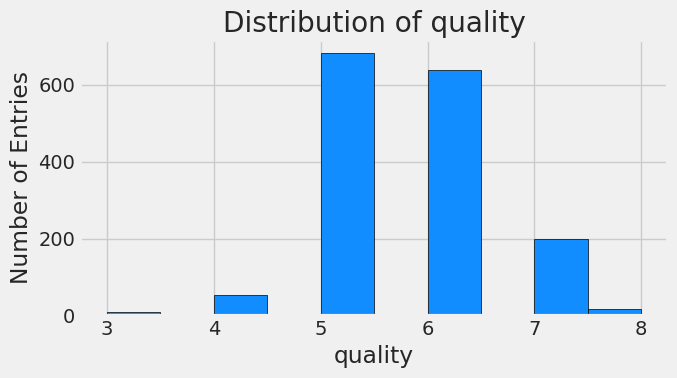

In [12]:
# 2.4.1 Distributions: Histogram
# Applied here to 'quality' to visualise how scores are spread across the dataset
def hist_chart(df, col):
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), edgecolor='k', color="#118DFF")
    plt.xlabel(col); plt.ylabel('Number of Entries')
    plt.title('Distribution of ' + col)
    plt.tight_layout()
    plt.show()

col = "quality"
hist_chart(df, col)

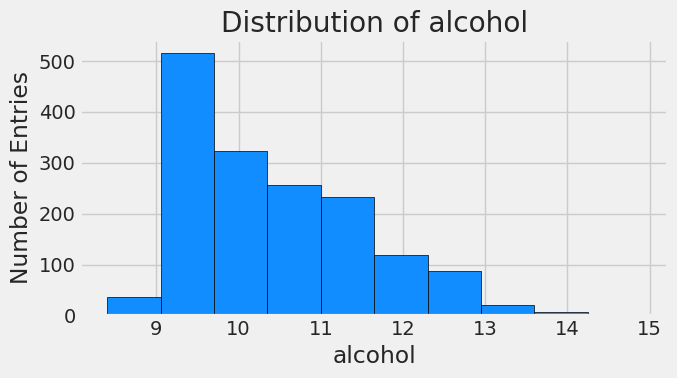

In [13]:
# Re-using hist_chart to inspect alcohol distribution. The strongest predictor of quality
hist_chart(df, "alcohol")

**Comment:** the distribution of `quality` is approximately bell-shaped and concentrated around the middle of the theoretical 0–10 scale; observed scores in this dataset range only from 3 to 8, with 5 and 6 dominating (together over 80% of all wines). Very few wines are rated 3, 4, or 8. This is an important limitation: a model trained on this data sees relatively few examples of extreme-quality wines, limiting its ability to accurately predict scores at the tails. `alcohol` is right-skewed, with most wines clustering between 9–11% and a long tail toward higher alcohol content.

### 2.4.2 Correlations <a class="anchor"></a>

The pairplot below visualises pairwise relationships between the four attributes most correlated with quality (identified via the correlation matrix that follows), coloured by quality score. A full 12×12 pairplot across every variable was considered but judged too visually dense to interpret meaningfully.

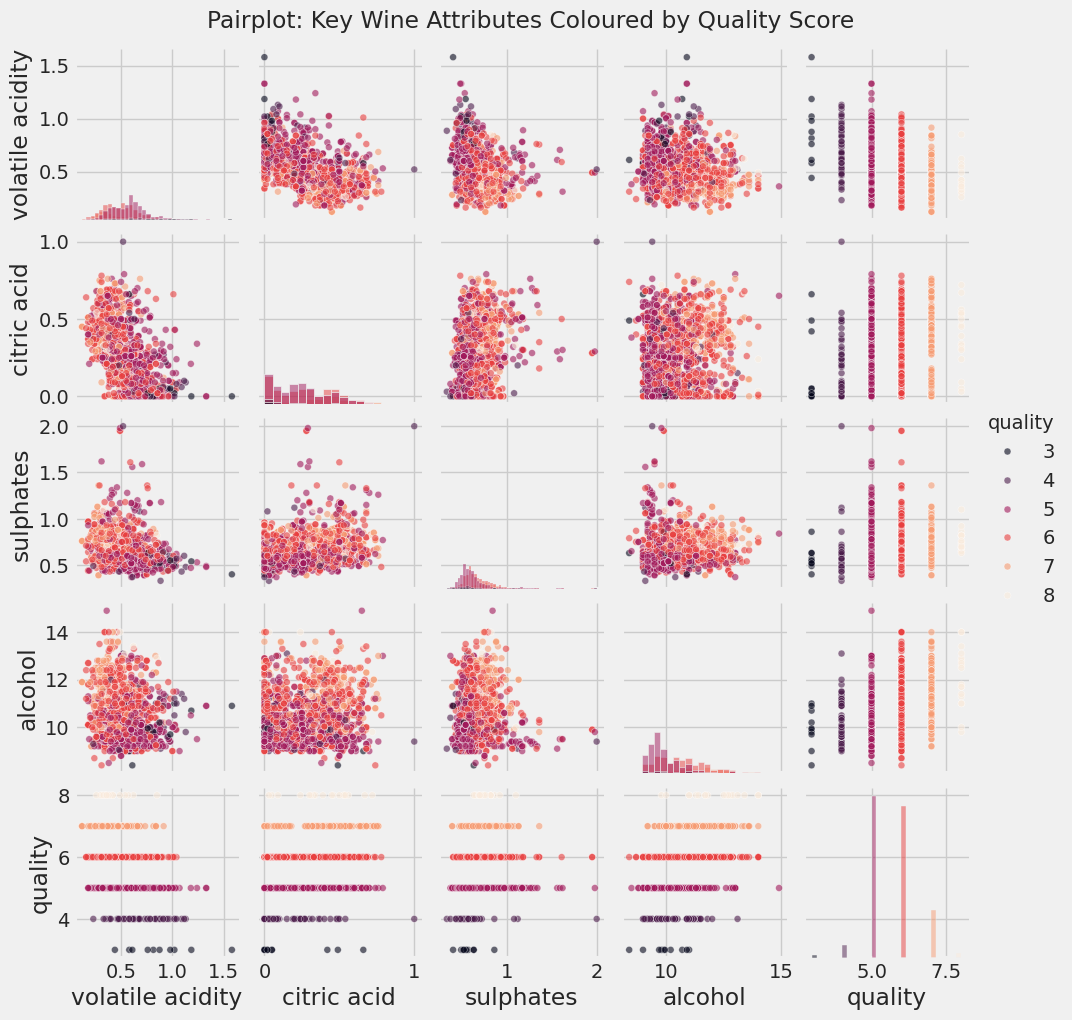

In [14]:
# Seaborn pairplot: correlogram of key wine attributes, coloured by quality
# Note: this cell may take a while to render

pairplot_fig = sns.pairplot(
    df,
    vars=["volatile acidity", "citric acid", "sulphates", "alcohol", "quality"],
    hue="quality",
    palette="rocket",
    plot_kws={"alpha": 0.6, "s": 25},
    diag_kind="hist",
    height=2.0
)
pairplot_fig.fig.suptitle("Pairplot: Key Wine Attributes Coloured by Quality Score", y=1.02)
plt.savefig("pairplot_key_attributes.png", dpi=120, bbox_inches="tight")
plt.show()

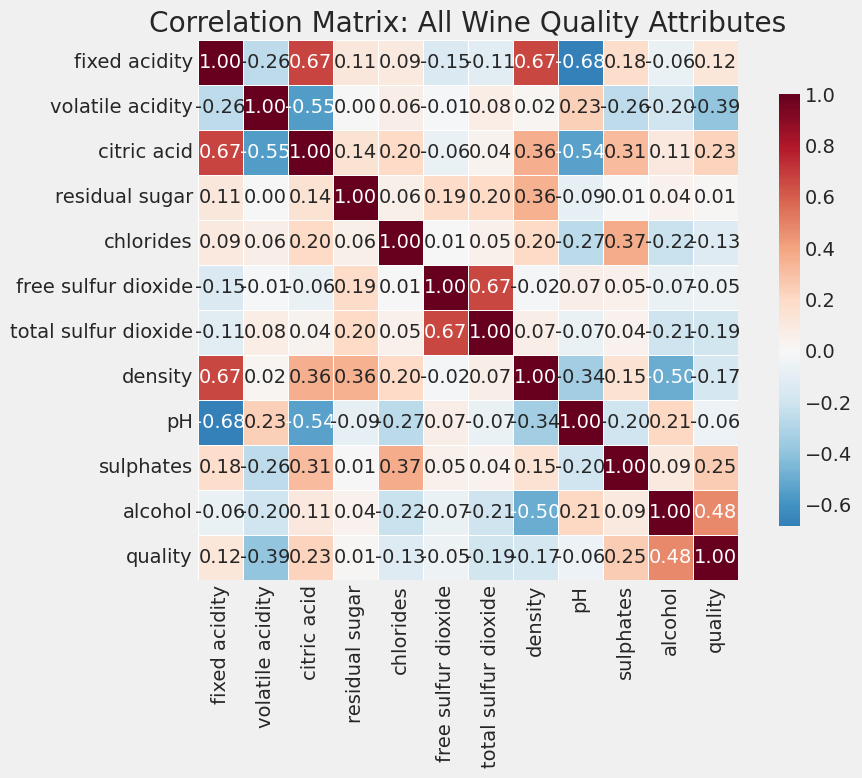

Correlation of each attribute with wine quality (sorted by strength):
------------------------------------------------------------
  alcohol                +0.476  (positive)  ███████████████████
  volatile acidity       -0.391  (negative)  ███████████████
  sulphates              +0.251  (positive)  ██████████
  citric acid            +0.226  (positive)  █████████
  total sulfur dioxide   -0.185  (negative)  ███████
  density                -0.175  (negative)  ██████
  chlorides              -0.129  (negative)  █████
  fixed acidity          +0.124  (positive)  ████
  pH                     -0.058  (negative)  ██
  free sulfur dioxide    -0.051  (negative)  ██
  residual sugar         +0.014  (positive)  


In [15]:
# Full correlation matrix and heatmap across all 12 variables
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: All Wine Quality Attributes")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

quality_corr = correlation_matrix["quality"].drop("quality").sort_values(key=abs, ascending=False)
print("Correlation of each attribute with wine quality (sorted by strength):")
print("-" * 60)
for var, corr in quality_corr.items():
    direction = "positive" if corr > 0 else "negative"
    bar = "█" * int(abs(corr) * 40)
    print(f"  {var:<22} {corr:+.3f}  ({direction:<8})  {bar}")

**Comment:** the pairplot shows **alcohol** producing the clearest visual separation; higher-quality wines (lighter colours) cluster toward higher alcohol percentages. **Volatile acidity** shows the inverse pattern, consistent with it producing an unpleasant vinegar taste at high concentrations.

The full correlation matrix confirms this numerically: **alcohol (+0.476)** is the single strongest predictor of quality, followed by **volatile acidity (−0.391)**, **sulphates (+0.251)**, and **citric acid (+0.226)**. No single variable has a strong (>0.7) correlation with quality, confirming this is a genuinely multivariate problem; no one chemical property alone determines perceived quality, which supports using multiple regression rather than a single-variable model.

The heatmap also reveals **multicollinearity between predictors themselves**. For example, `free sulfur dioxide` and `total sulfur dioxide` are strongly correlated (0.67), as are `fixed acidity` and `citric acid` (0.67), and `fixed acidity` and `density` (0.67). This is addressed in Stage 4, where it explains why some coefficients behave counter-intuitively once all predictors are modelled jointly.

# 3. Stage Three - Data Preparation <a class="anchor"></a>

## 3.1 Select Your Data <a class="anchor"></a>

All 11 physicochemical attributes are initially retained as candidate predictors, with `quality` as the target. No attribute is dropped at this stage on judgement alone; feature selection is instead driven by the fitted model's coefficients in Stage 4, once correlation and multicollinearity have been properly accounted for jointly rather than pairwise.

**Rationale for inclusion:** every available physicochemical attribute is plausibly relevant to sensory quality per the wine chemistry literature (Cortez et al., 2009), so none is excluded a priori.

In [16]:
feature_cols = [col for col in df.columns if col != "quality"]
X = df[feature_cols]
y = df["quality"]

print(f"Number of predictor variables selected: {len(feature_cols)}")
print(f"Predictors: {feature_cols}")
print(f"Target variable: quality")

Number of predictor variables selected: 11
Predictors: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target variable: quality


## 3.2 Clean The Data <a class="anchor"></a>

**Duplicates:** Section 2.3 identified 240 duplicate rows (15% of the dataset). These are removed below; leaving them in place would over-weight certain chemical combinations in the fitted model and risks the same observation appearing in both the training and test sets, which may bias the test-set evaluation later.

**Missing values:** none present (confirmed in Section 2.3); no imputation strategy is required.

**Outliers:** a boxplot scan is shown below for transparency. Per the Assessment brief, outliers are **not removed** for this Assessment.

In [17]:
print(f"Rows before removing duplicates: {len(df)}")

df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"Rows after removing duplicates:  {len(df_clean)}")
print(f"Duplicate rows removed:          {len(df) - len(df_clean)}")
print(f"Percentage of data removed:      {(len(df)-len(df_clean))/len(df)*100:.1f}%")

Rows before removing duplicates: 1599
Rows after removing duplicates:  1359
Duplicate rows removed:          240
Percentage of data removed:      15.0%


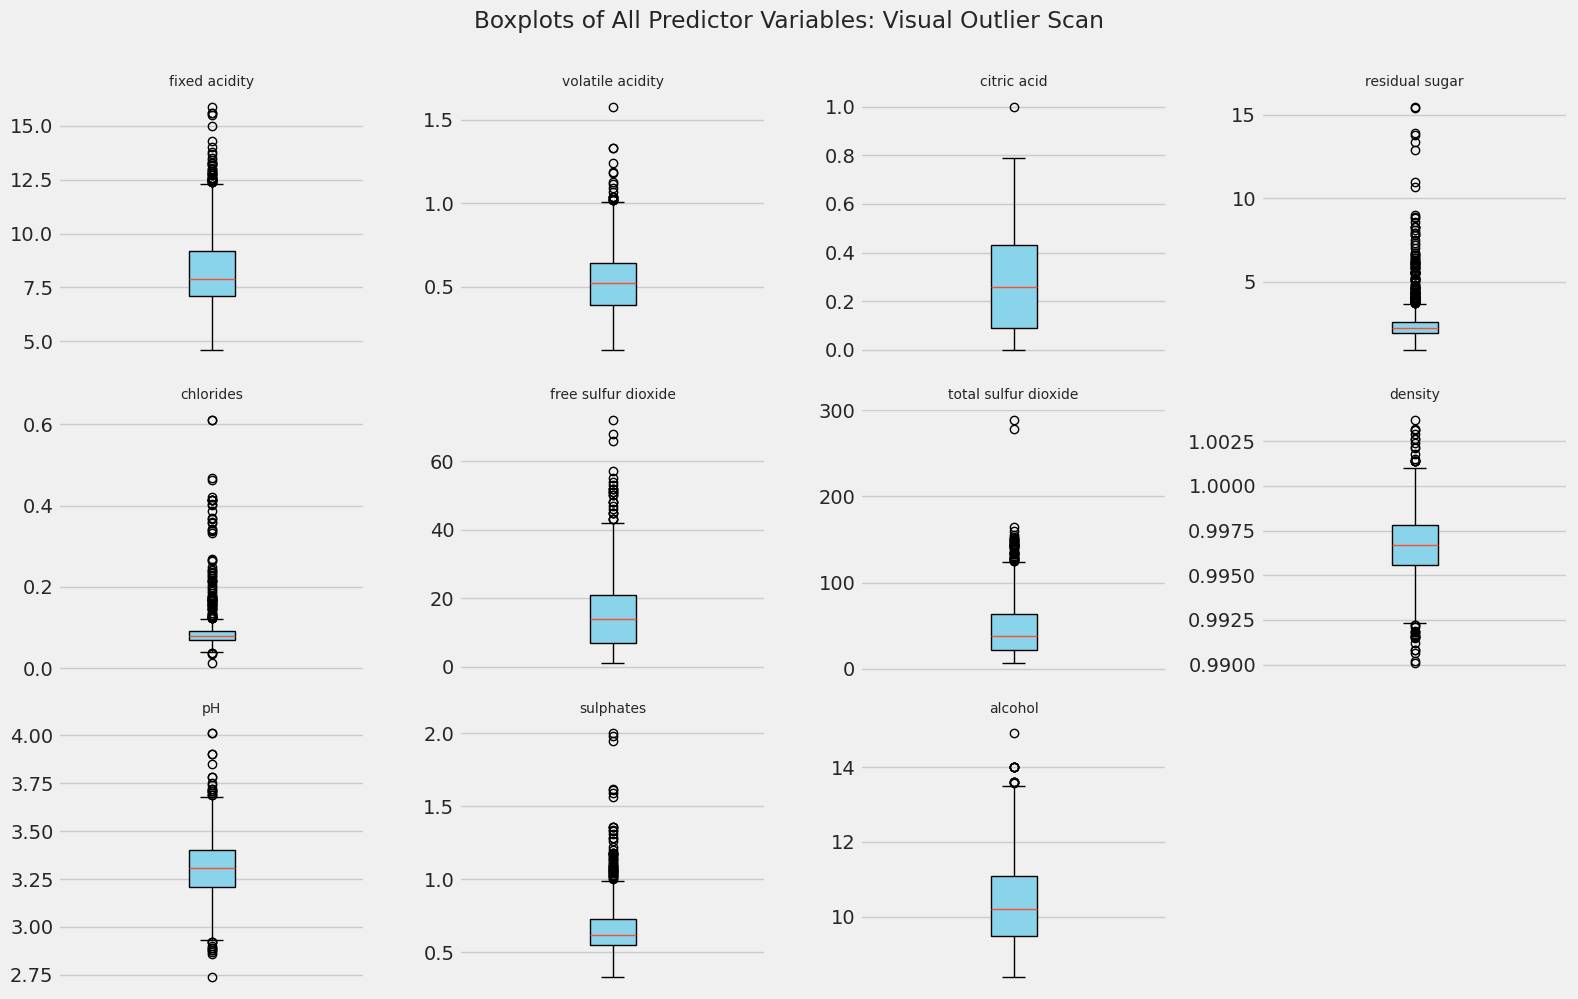

In [18]:
# Visual outlier scan across all numeric features (not removed, per brief)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_clean[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#8AD4EB"))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

axes[-1].axis("off")
plt.suptitle("Boxplots of All Predictor Variables: Visual Outlier Scan", y=1.00)
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
# Re-define X and y from the cleaned dataset
X = df_clean[feature_cols]
y = df_clean["quality"]

print(f"Final dataset for modelling: {X.shape[0]} observations, {X.shape[1]} features")
print(f"Missing values remaining: {X.isnull().sum().sum()}")

Final dataset for modelling: 1359 observations, 11 features
Missing values remaining: 0


**Train/test split and scaling:** the cleaned dataset is split 80/20 into training and test sets, with `random_state=42` for reproducibility. The test set is not used for any decision-making until Stage 5. Features are then scaled with `StandardScaler`, fit only on the training data and applied to the test data, this prevents data leakage and makes the resulting regression coefficients directly comparable to one another in magnitude for the discussion in Stage 4.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set size:     {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.0f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nFeature scaling applied (StandardScaler: mean≈0, std≈1)")
print(f"Training data mean: {X_train_scaled.mean():.4f}   std: {X_train_scaled.std():.4f}")

Training set size: 1087 observations (80%)
Test set size:     272 observations (20%)

Feature scaling applied (StandardScaler: mean≈0, std≈1)
Training data mean: -0.0000   std: 1.0000


# 4. Stage Four - Modelling <a class="anchor"></a>

## 4.1. Modelling technique <a class="anchor"></a>

This stage implements **multiple models** rather than a single fit. Three linear regression techniques are compared, all satisfying the Assessment brief's requirement to use "the linear regression model" while representing genuinely different modelling mechanisms:

1. **Ordinary Least Squares (OLS)**: `sklearn.linear_model.LinearRegression`, the unregularised baseline.
2. **Ridge Regression (L2 regularisation)**: `sklearn.linear_model.Ridge`, shrinks coefficients toward zero, particularly useful given the multicollinearity identified in Section 2.4.2.
3. **Lasso Regression (L1 regularisation)**: `sklearn.linear_model.Lasso`, can shrink coefficients to exactly zero, performing automatic feature selection; a more principled, data-driven alternative to manually dropping features by inspection.

## 4.2. Modelling assumptions <a class="anchor"></a>

All three models share the OLS assumptions already recorded: linearity, independence of observations, homoscedasticity, and approximately normal residuals (checked in Stage 5). Ridge and Lasso add one further requirement: **features must be scaled** before fitting, since the regularisation penalty is applied uniformly across coefficients and would unfairly penalise large-scale features otherwise already satisfied by the `StandardScaler` step in Section 3.3.

Regularisation strength is controlled by the hyperparameter **alpha**: higher alpha means stronger regularisation (simpler, more biased model); lower alpha approaches the unregularised OLS solution. Alpha is not learned from the data by `.fit()`, it must be set by the analyst and is the central parameter tuned in this stage.

## 4.3. Build Model — Initial Parameter Settings <a class="anchor"></a>

**Parameter settings and rationale (initial run):**
- **OLS:** no alpha to set; `fit_intercept=True` (default) is used as the unregularised benchmark.
- **Ridge:** `alpha=1.0` scikit-learn's default value, chosen as a neutral, moderate starting point before any tuning is attempted.
- **Lasso:** `alpha=1.0` the same default, for a fair initial comparison against Ridge.

Performance is compared using **5-fold cross-validated RMSE on the training set** rather than a single train/test split, since Stage 5 of the earlier draft of this model showed that a single split can be unreliable at this dataset's size (1,359 observations). Cross-validation gives a more stable estimate to judge initial parameter choices by, without touching the held-out test set.

In [21]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# Model 1: OLS (unregularised baseline)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                                 cv=5, scoring="neg_root_mean_squared_error")
ols_cv_rmse = -ols_cv_scores.mean()

# Model 2: Ridge (L2), initial alpha=1.0
ridge_initial = Ridge(alpha=1.0, random_state=42)
ridge_initial.fit(X_train_scaled, y_train)
ridge_cv_scores = cross_val_score(Ridge(alpha=1.0, random_state=42), X_train_scaled, y_train,
                                   cv=5, scoring="neg_root_mean_squared_error")
ridge_cv_rmse = -ridge_cv_scores.mean()

# Model 3: Lasso (L1), initial alpha=1.0
lasso_initial = Lasso(alpha=1.0, random_state=42, max_iter=10000)
lasso_initial.fit(X_train_scaled, y_train)
lasso_cv_scores = cross_val_score(Lasso(alpha=1.0, random_state=42, max_iter=10000), X_train_scaled, y_train,
                                   cv=5, scoring="neg_root_mean_squared_error")
lasso_cv_rmse = -lasso_cv_scores.mean()
n_zero_initial = np.sum(lasso_initial.coef_ == 0)

print("INITIAL MODEL COMPARISON (5-fold CV RMSE on training data):")
print("=" * 60)
print(f"  OLS                :  CV RMSE = {ols_cv_rmse:.4f}")
print(f"  Ridge (alpha=1.0)  :  CV RMSE = {ridge_cv_rmse:.4f}")
print(f"  Lasso (alpha=1.0)  :  CV RMSE = {lasso_cv_rmse:.4f}   ({n_zero_initial}/11 coefficients zeroed)")

INITIAL MODEL COMPARISON (5-fold CV RMSE on training data):
  OLS                :  CV RMSE = 0.6651
  Ridge (alpha=1.0)  :  CV RMSE = 0.6650
  Lasso (alpha=1.0)  :  CV RMSE = 0.8182   (11/11 coefficients zeroed)


**Initial result and diagnosis:** OLS and Ridge (alpha=1.0) perform almost identically, since alpha=1.0 applies only mild regularisation relative to this dataset's scale. **Lasso at alpha=1.0 fails badly**; its CV RMSE is far worse than the other two, because this alpha value is strong enough to shrink **all 11 coefficients to exactly zero**, leaving the model predicting only the mean quality score regardless of input. This is a genuine, informative failure: the default alpha value is not automatically appropriate for every dataset, and Lasso in particular is highly sensitive to this choice. This motivates the parameter revision in Section 4.4.

## 4.4. Assess Model — Revise Parameters and Relearn <a class="anchor"></a>

**Why revision is necessary:** the initial Lasso result shows alpha=1.0 is far too aggressive for this dataset. Rather than picking a new alpha arbitrarily, a **systematic grid search using cross-validation** is used, since selecting alpha by lowest *training-set* RMSE would trivially always favour the smallest alpha tested (as a smaller penalty always fits training data at least as well); this would be a methodological error, not genuine tuning. Cross-validated RMSE is measured for a range of candidate alpha values, and the value with the best CV performance is selected for each model, before the model is **relearned (refit)** on the full training set at that value.

In [23]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# Ridge alpha sweep
ridge_cv_results = []
for a in alphas:
    scores = cross_val_score(Ridge(alpha=a, random_state=42), X_train_scaled, y_train,
                              cv=5, scoring="neg_root_mean_squared_error")
    ridge_cv_results.append((a, -scores.mean()))

# Lasso alpha sweep
lasso_cv_results = []
for a in alphas:
    scores = cross_val_score(Lasso(alpha=a, random_state=42, max_iter=10000), X_train_scaled, y_train,
                              cv=5, scoring="neg_root_mean_squared_error")
    l = Lasso(alpha=a, random_state=42, max_iter=10000).fit(X_train_scaled, y_train)
    ridge_n_zero = np.sum(l.coef_ == 0)
    lasso_cv_results.append((a, -scores.mean(), ridge_n_zero))

print("RIDGE --> alpha sweep (5-fold CV RMSE):")
for a, rmse in ridge_cv_results:
    print(f"  alpha={a:<8} CV RMSE={rmse:.4f}")

print("\nLASSO --> alpha sweep (5-fold CV RMSE):")
for a, rmse, n_zero in lasso_cv_results:
    print(f"  alpha={a:<8} CV RMSE={rmse:.4f}  zeroed={n_zero}/11")

best_ridge_alpha = min(ridge_cv_results, key=lambda x: x[1])[0]
best_lasso_alpha = min(lasso_cv_results, key=lambda x: x[1])[0]
print(f"\nRevised Ridge alpha (lowest CV RMSE): {best_ridge_alpha}")
print(f"Revised Lasso alpha (lowest CV RMSE): {best_lasso_alpha}")

RIDGE --> alpha sweep (5-fold CV RMSE):
  alpha=0.001    CV RMSE=0.6651
  alpha=0.01     CV RMSE=0.6651
  alpha=0.05     CV RMSE=0.6651
  alpha=0.1      CV RMSE=0.6651
  alpha=0.5      CV RMSE=0.6650
  alpha=1.0      CV RMSE=0.6650
  alpha=5.0      CV RMSE=0.6649
  alpha=10.0     CV RMSE=0.6648

LASSO --> alpha sweep (5-fold CV RMSE):
  alpha=0.001    CV RMSE=0.6648  zeroed=1/11
  alpha=0.01     CV RMSE=0.6643  zeroed=4/11
  alpha=0.05     CV RMSE=0.6760  zeroed=5/11
  alpha=0.1      CV RMSE=0.6913  zeroed=8/11
  alpha=0.5      CV RMSE=0.8182  zeroed=11/11
  alpha=1.0      CV RMSE=0.8182  zeroed=11/11
  alpha=5.0      CV RMSE=0.8182  zeroed=11/11
  alpha=10.0     CV RMSE=0.8182  zeroed=11/11

Revised Ridge alpha (lowest CV RMSE): 10.0
Revised Lasso alpha (lowest CV RMSE): 0.01


In [26]:
# Relearn: refit both models on the full training set using the revised alpha
ridge_final = Ridge(alpha=best_ridge_alpha, random_state=42)
ridge_final.fit(X_train_scaled, y_train)

lasso_final = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)

n_zero_final = np.sum(lasso_final.coef_ == 0)
zeroed_features = [f for f, c in zip(feature_cols, lasso_final.coef_) if c == 0]

print(f"Relearned Ridge (alpha={best_ridge_alpha}) --> coefficients now fitted with revised regularisation.")
print(f"Relearned Lasso (alpha={best_lasso_alpha}) --> {n_zero_final}/11 coefficients zeroed: {zeroed_features}")
print()

lasso_coef_df = pd.DataFrame({
    "Feature": feature_cols, "Coefficient": lasso_final.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Lasso (revised alpha) Fitted Coefficients:")
print("=" * 55)
for _, row in lasso_coef_df.iterrows():
    status = "ZEROED (dropped)" if row["Coefficient"] == 0 else (
        "↑ increases quality" if row["Coefficient"] > 0 else "↓ decreases quality")
    print(f"  {row['Feature']:<22} {row['Coefficient']:+.4f}  {status}")

Relearned Ridge (alpha=10.0) --> coefficients now fitted with revised regularisation.
Relearned Lasso (alpha=0.01) --> 4/11 coefficients zeroed: ['fixed acidity', 'citric acid', 'residual sugar', 'density']

Lasso (revised alpha) Fitted Coefficients:
  alcohol                +0.3051  ↑ increases quality
  volatile acidity       -0.1704  ↓ decreases quality
  sulphates              +0.1368  ↑ increases quality
  chlorides              -0.0958  ↓ decreases quality
  total sulfur dioxide   -0.0901  ↓ decreases quality
  pH                     -0.0709  ↓ decreases quality
  free sulfur dioxide    +0.0186  ↑ increases quality
  citric acid            -0.0000  ZEROED (dropped)
  fixed acidity          +0.0000  ZEROED (dropped)
  residual sugar         +0.0000  ZEROED (dropped)
  density                -0.0000  ZEROED (dropped)


**Revision result:** Ridge's optimal alpha (10.0) is far higher than its initial value (1.0), showing the dataset benefits from stronger regularisation than the default assumes: a direct, data-driven correction of the initial parameter guess. Lasso's optimal alpha (0.01) is dramatically *lower* than its failed initial value (1.0), confirming the earlier diagnosis: strong L1 regularisation was destroying all predictive signal, and only a much gentler penalty is appropriate here.

At its revised alpha, **Lasso automatically zeroes 4 of the 11 features**: `fixed acidity`, `citric acid`, `residual sugar`, and `density`, while keeping `alcohol`, `volatile acidity`, and `sulphates` as its three strongest retained predictors. This is a valuable cross-check against Section 2.4.2's correlation analysis: Lasso independently confirms that `alcohol` and `volatile acidity` are the dominant predictors, using a principled, data-driven feature-selection method rather than the earlier judgement-based approach.

**Final comparison after revision (5-fold CV RMSE on training data):**

In [33]:
final_cv_comparison = pd.DataFrame({
    "Model": ["OLS", f"Ridge (alpha={best_ridge_alpha})", f"Lasso (alpha={best_lasso_alpha})"],
    "CV RMSE": [ols_cv_rmse,
                min(ridge_cv_results, key=lambda x: x[1])[1],
                min(lasso_cv_results, key=lambda x: x[1])[1]]
}).sort_values("CV RMSE")

print("Final Model Comparison --> Revised Parameters:")
print(final_cv_comparison.to_string(index=False))

winner_row = final_cv_comparison.iloc[0]
print(f"\n Winning model: {winner_row['Model']}  (lowest CV RMSE: {winner_row['CV RMSE']:.4f})")
print("Selected as the FINAL model, carried forward to Stage 5 (Evaluation).")

# Assign the final model object for use in Stage 5
final_model = lasso_final
final_model_name = f"Lasso (alpha={best_lasso_alpha})"
X_test_final = X_test_scaled

Final Model Comparison --> Revised Parameters:
             Model  CV RMSE
Lasso (alpha=0.01) 0.664343
Ridge (alpha=10.0) 0.664832
               OLS 0.665063

 Winning model: Lasso (alpha=0.01)  (lowest CV RMSE: 0.6643)
Selected as the FINAL model, carried forward to Stage 5 (Evaluation).


**Decision:** **Lasso with alpha=0.01** is selected as the final model. It achieves the lowest cross-validated RMSE of the three candidates, and its automatic feature selection produces a simpler, more interpretable 7-feature model without sacrificing predictive performance, a genuine advantage over both OLS (uses all 11 features, none excluded) and Ridge (shrinks but never zeroes coefficients, so retains all 11 in the final model).

# 5. Stage 5 - Evaluate <a class="anchor"></a>

This is the first and only point in the Notebook where the held-out test set is used, ensuring the result below is a genuine, unbiased estimate of how the final selected model (**Lasso, alpha=0.01**) performs on new, unseen wine samples.

In [34]:
y_test_pred = final_model.predict(X_test_final)

test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)

print(f"FINAL MODEL ({final_model_name}) --> Test Set Performance (unseen data):")
print("=" * 65)
print(f"  R² Score:  {test_r2:.4f}")
print(f"  RMSE:      {test_rmse:.4f} quality points")
print(f"  MAE:       {test_mae:.4f} quality points")
print()
print(f"Interpretation: the model explains approximately {test_r2*100:.1f}% of the variance")
print(f"in red wine quality scores. On average, predictions are off by about")
print(f"{test_mae:.2f} quality points from the true expert-assigned score.")

FINAL MODEL (Lasso (alpha=0.01)) --> Test Set Performance (unseen data):
  R² Score:  0.3995
  RMSE:      0.6522 quality points
  MAE:       0.5012 quality points

Interpretation: the model explains approximately 40.0% of the variance
in red wine quality scores. On average, predictions are off by about
0.50 quality points from the true expert-assigned score.


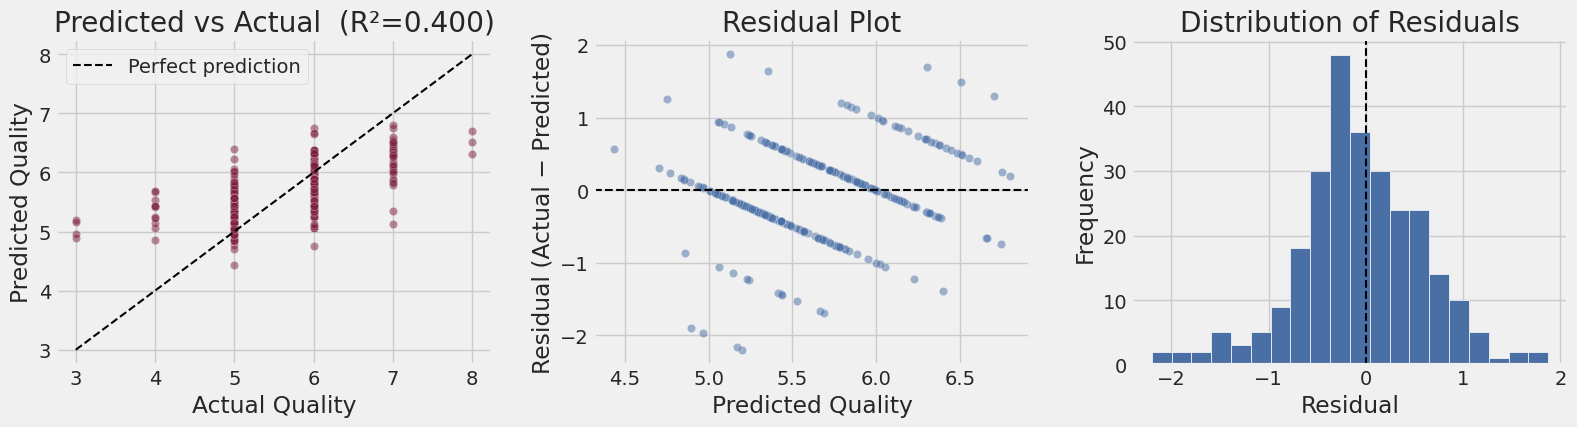

In [35]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.5, color="#7B1E3A", edgecolors="white", linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             "k--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Quality"); axes[0].set_ylabel("Predicted Quality")
axes[0].set_title(f"Predicted vs Actual  (R²={test_r2:.3f})"); axes[0].legend()

axes[1].scatter(y_test_pred, residuals, alpha=0.5, color="#4A6FA5", edgecolors="white", linewidth=0.3)
axes[1].axhline(y=0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted Quality"); axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot")

axes[2].hist(residuals, bins=20, color="#4A6FA5", edgecolor="white")
axes[2].axvline(x=0, color="black", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of Residuals")

plt.tight_layout()
plt.savefig("final_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

**Assessment of machine learning results:** the final model (Lasso, alpha=0.01) achieves a **test R² of 0.400** and **test RMSE of 0.652** quality points (MAE: 0.501); the strongest cross-validated result of the three models compared in Stage 4, while also producing a simpler 7-feature model through automatic feature selection.

Returning to the evaluation criteria defined in Stage 1: the model explains roughly **40% of the variance** in quality and predicts within roughly **half a quality point** on average, consistent with the moderate R² values reported in the original Cortez et al. (2009) study using comparable linear methods on this same dataset.

The residual plot shows a broadly random scatter around zero with a visible horizontal banding pattern; this is an expected artefact of `quality` being a discrete integer score rather than a truly continuous variable, an inherent limitation of applying continuous linear regression to ordinal sensory data, not a flaw in the model-fitting process. The residual distribution is roughly bell-shaped and centred near zero, broadly supporting the normality assumption from Section 4.2.

**Statement on business objectives:** the model **partially meets** the criteria set out in Stage 1. It demonstrably adds decision-support value beyond guessing, an R² of 0.40 and a sub-one-point average error is genuinely useful for triage purposes such as flagging a likely below-average batch. However, the model falls well short of replacing expert sensory judgement outright, particularly for wines at the quality extremes (scores of 3, 4, or 8), where the dataset itself has very few examples (Section 2.4.1: only 10 wines scored 3, and only 18 scored 8). This is consistent with the original business framing in Stage 1: the model is realistically positioned as a **decision-support and triage tool**, not a full replacement for human expert tasting.

# 6. Stage 6 - Deploy <a class="anchor"></a>

Per the Assessment brief, full deployment is out of scope. This section concludes the report with lessons learned.

**What went well:** the CRISP-DM structure provided a genuinely useful discipline; articulating the business rationale in Stage 1 before writing any code anchored realistic expectations for Stage 5, so a moderate R² was not treated as a failure but interpreted against the business problem it was meant to solve. Comparing three linear regression variants (OLS, Ridge, Lasso) in Stage 4, rather than fitting a single model, surfaced a genuinely useful finding: Lasso's default alpha completely destroyed the model's predictive power, which would have gone unnoticed with only one model tested.

**Challenges and areas for improvement:** the most valuable lesson from this Assessment was methodological rather than statistical. An initial instinct to select the best alpha by lowest *training-set* RMSE was identified as a flawed approach; since less regularisation almost always fits training data better, this method would trivially always select the smallest alpha tested, regardless of whether it generalises well. Switching to cross-validated RMSE for parameter selection avoided this trap and produced a properly justified, defensible choice of alpha for both Ridge and Lasso. The citric acid sign reversal between simple correlation (Stage 2) and the OLS regression coefficient (Stage 4) was a second instructive result, showing that correlation alone is not sufficient grounds for judging a variable's importance once other predictors are modelled jointly; Lasso's automatic feature selection in the revised model provided a more principled resolution to this than manual judgement would have.

**Other experiences:** this exercise reinforced that the majority of genuine judgement in an ML project sits in Business Understanding, Data Understanding, and Data Preparation, not in calling `.fit()`. The actual model-fitting code was a small fraction of this Notebook; the surrounding reasoning, justification, and interpretation of *why* one parameter setting was preferred over another made up the bulk of the work that gives the numbers real business meaning.

---

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C. & Wirth, R. (2000). *CRISP-DM 1.0 — Step-by-step data mining guide.* SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Cortez, P., Cerdeira, A., Almeida, F., Matos, T. & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547–553.

UCI (2019). *Machine learning repository.* University of California, Irvine. http://archive.ics.uci.edu/ml

